# Recurrent Neural Networks (RNN): Learning Sequential Patterns in Text

This is the fourth notebook in the **AI NLP LLM Notes** learning path.

The previous notebooks covered TF-IDF, word vectors, and learned word embeddings. This notebook continues from embeddings and introduces **Recurrent Neural Networks (RNNs)**: neural networks designed to process ordered sequences.

# Introduction

TF-IDF represents documents with sparse lexical features. Word embeddings represent words with dense vectors learned from data.

However, language is not just a collection of words. It is a **sequence**. Word order changes meaning, and many NLP tasks depend on information that appears earlier in a sentence.

RNNs were introduced to process one token at a time while preserving information from previous tokens through a hidden state. This made them a natural early neural architecture for language modeling, sentiment analysis, sequence labeling, and machine translation.

## Why Feedforward Networks Fail for NLP

A feedforward neural network receives a fixed-size input and processes it in one pass. That works well for many tabular tasks, but it is awkward for language because sentences have variable length and meaningful order.

Consider:

- `Dog bites man`
- `Man bites dog`

Both sentences contain the same words, but they do not mean the same thing. Embeddings alone can represent individual words, but they do not automatically model how meaning changes when word order changes.

Sequential architectures are needed because the model must know not only **which words** appear, but also **when** they appear.

In [1]:
#!pip install tensorflow keras
import random
import re
import string
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

try:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.utils import to_categorical

    # This notebook uses a tiny educational dataset; CPU is usually faster and
    # more predictable than Apple Metal/GPU for this SimpleRNN example.
    try:
        tf.config.set_visible_devices([], "GPU")
    except (RuntimeError, ValueError):
        pass
except ImportError as error:
    raise ImportError(
        "This notebook requires TensorFlow. Install it with: pip install tensorflow"
    ) from error


In [2]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "axes.facecolor": "#FAFAFA",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "#222222",
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "font.family": "DejaVu Sans",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "-",
        "grid.linewidth": 0.8,
        "xtick.color": "#222222",
        "ytick.color": "#222222",
    }
)

PRIMARY_COLOR = "#2F6F9F"
SECONDARY_COLOR = "#D95F59"
ACCENT_COLOR = "#3A9D7C"
WARNING_COLOR = "#E0A23B"
NEUTRAL_COLOR = "#6B7280"

## What is a Recurrent Neural Network?

A **Recurrent Neural Network** processes a sequence step by step. At each time step, it receives the current input token and the previous hidden state.

The hidden state acts like a compact memory:

\[
h_t = f(x_t, h_{t-1})
\]

where:

- `x_t` is the input at time step `t`,
- `h_t` is the hidden state at time step `t`,
- `h_{t-1}` carries information from previous tokens.

The same RNN weights are reused at each time step, which allows the model to process variable-length sequences.

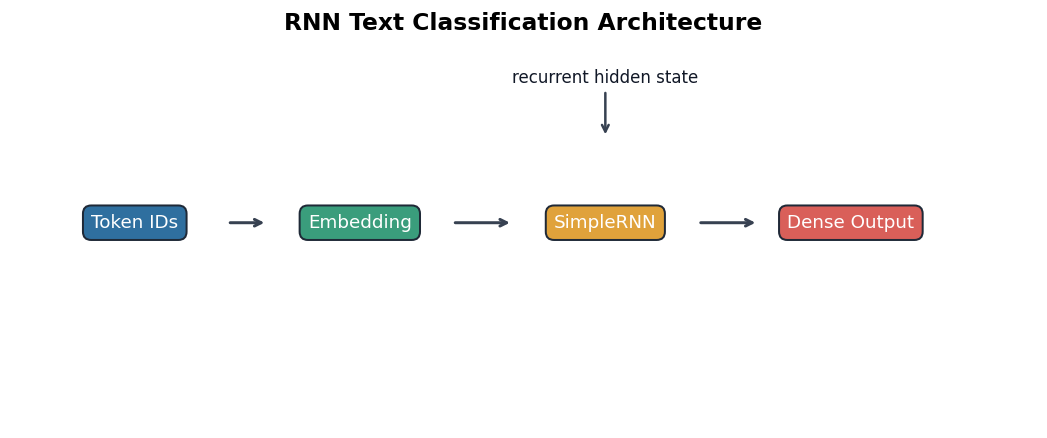

In [3]:
def draw_rnn_architecture():
    """Draw a compact RNN architecture diagram with matplotlib."""
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.axis("off")

    layers = [
        ("Token IDs", 0.12, PRIMARY_COLOR),
        ("Embedding", 0.34, ACCENT_COLOR),
        ("SimpleRNN", 0.58, WARNING_COLOR),
        ("Dense Output", 0.82, SECONDARY_COLOR),
    ]

    for label, x_position, color in layers:
        ax.text(
            x_position,
            0.55,
            label,
            ha="center",
            va="center",
            fontsize=11,
            color="white",
            bbox={
                "boxstyle": "round,pad=0.45",
                "facecolor": color,
                "edgecolor": "#1F2937",
                "linewidth": 1.2,
            },
        )

    for (_, start, _), (_, end, _) in zip(layers[:-1], layers[1:]):
        ax.annotate(
            "",
            xy=(end - 0.09, 0.55),
            xytext=(start + 0.09, 0.55),
            arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#374151"},
        )

    ax.annotate(
        "recurrent hidden state",
        xy=(0.58, 0.78),
        xytext=(0.58, 0.93),
        ha="center",
        arrowprops={"arrowstyle": "->", "lw": 1.5, "color": "#374151"},
        fontsize=10,
        color="#111827",
    )
    ax.set_title("RNN Text Classification Architecture", pad=16)
    plt.show()


draw_rnn_architecture()

## Understanding the Hidden State

The hidden state is updated as the model reads the sequence:

`x1 → h1`, `x2 → h2`, `x3 → h3`

Each new hidden state combines the current token representation with information carried from the previous step. This is how an RNN can make later predictions depend on earlier words.

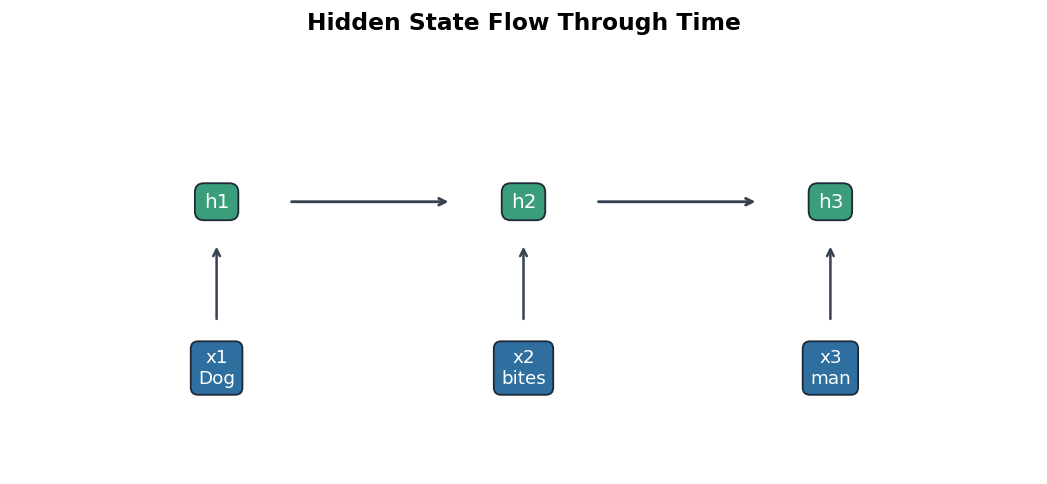

In [4]:
def draw_hidden_state_flow():
    """Draw hidden state flow across three time steps."""
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.axis("off")

    x_positions = [0.2, 0.5, 0.8]
    tokens = ["x1\nDog", "x2\nbites", "x3\nman"]
    states = ["h1", "h2", "h3"]

    for x_position, token, state in zip(x_positions, tokens, states):
        ax.text(
            x_position,
            0.25,
            token,
            ha="center",
            va="center",
            fontsize=11,
            bbox={
                "boxstyle": "round,pad=0.4",
                "facecolor": PRIMARY_COLOR,
                "edgecolor": "#1F2937",
                "linewidth": 1.1,
            },
            color="white",
        )
        ax.text(
            x_position,
            0.65,
            state,
            ha="center",
            va="center",
            fontsize=12,
            bbox={
                "boxstyle": "round,pad=0.45",
                "facecolor": ACCENT_COLOR,
                "edgecolor": "#1F2937",
                "linewidth": 1.1,
            },
            color="white",
        )
        ax.annotate(
            "",
            xy=(x_position, 0.55),
            xytext=(x_position, 0.36),
            arrowprops={"arrowstyle": "->", "lw": 1.5, "color": "#374151"},
        )

    for start, end in zip(x_positions[:-1], x_positions[1:]):
        ax.annotate(
            "",
            xy=(end - 0.07, 0.65),
            xytext=(start + 0.07, 0.65),
            arrowprops={"arrowstyle": "->", "lw": 1.7, "color": "#374151"},
        )

    ax.set_title("Hidden State Flow Through Time", pad=16)
    plt.show()


draw_hidden_state_flow()

## Dataset

We will build a small sentiment classification dataset with three labels:

- `positive`
- `negative`
- `neutral`

The sentences are short but realistic. They include examples from product reviews, customer support, software workflows, healthcare operations, finance, and education.

In [5]:
positive_sentences = [
    "The support team resolved my billing issue quickly",
    "The new dashboard makes reporting much easier",
    "I am satisfied with the product quality",
    "The mobile app feels fast and reliable",
    "Customer service gave a clear and helpful answer",
    "The model improved after the latest training run",
    "The documentation is easy to follow",
    "The deployment process was smooth today",
    "The analytics report provided useful insights",
    "The hospital portal helped patients book appointments",
    "The finance tool saved our team several hours",
    "The security update worked without any disruption",
    "The course content was practical and well organized",
    "The chatbot handled my request accurately",
    "The search results were relevant and complete",
    "The onboarding process felt simple and professional",
    "The recommendation engine suggested useful articles",
    "The API response time improved after optimization",
    "The team delivered the feature ahead of schedule",
    "The system recovered gracefully after maintenance",
    "The training session answered all important questions",
    "The user interface is clean and intuitive",
    "The payment confirmation arrived instantly",
    "The quality review passed without major issues",
]

negative_sentences = [
    "The app crashed during the payment process",
    "Customer support did not answer my question",
    "The dashboard is confusing and slow",
    "The latest update introduced several bugs",
    "The model predictions were inaccurate today",
    "The documentation is missing important setup steps",
    "The deployment failed without a clear error message",
    "The report contained outdated finance data",
    "The hospital portal rejected a valid appointment request",
    "The security alert arrived too late",
    "The course examples were unclear and incomplete",
    "The chatbot misunderstood the billing problem",
    "The search engine returned irrelevant documents",
    "The onboarding workflow took too long",
    "The API timeout caused a poor user experience",
    "The recommendation system repeated the same items",
    "The team missed the release deadline",
    "The system lost data during synchronization",
    "The training material was difficult to understand",
    "The user interface feels cluttered",
    "The payment failed but still showed a pending charge",
    "The quality review found serious regression issues",
    "The monitoring dashboard stopped refreshing",
    "The account recovery process was frustrating",
]

neutral_sentences = [
    "The support ticket was assigned to a specialist",
    "The dashboard displays weekly metrics",
    "The product update is scheduled for Friday",
    "The mobile app requires a network connection",
    "Customer service is available during business hours",
    "The model training job started this morning",
    "The documentation includes an installation section",
    "The deployment pipeline has three approval stages",
    "The analytics report covers the previous quarter",
    "The hospital portal stores appointment history",
    "The finance tool exports transaction summaries",
    "The security policy requires multi factor authentication",
    "The course contains five modules",
    "The chatbot collects account information before routing",
    "The search index updates every night",
    "The onboarding workflow includes identity verification",
    "The recommendation engine stores user preferences",
    "The API returns results in JSON format",
    "The team will review the feature tomorrow",
    "The system maintenance window starts at midnight",
    "The training session lasts ninety minutes",
    "The user interface includes a settings panel",
    "The payment receipt includes a transaction ID",
    "The quality review checklist has ten items",
]

dataset_rows = []
for label, sentences in [
    ("positive", positive_sentences),
    ("negative", negative_sentences),
    ("neutral", neutral_sentences),
]:
    dataset_rows.extend({"text": sentence, "label": label} for sentence in sentences)

dataset_df = pd.DataFrame(dataset_rows).sample(
    frac=1,
    random_state=RANDOM_SEED,
).reset_index(drop=True)

display(dataset_df.head(12))
print(f"Dataset size: {len(dataset_df)} sentences")
display(dataset_df["label"].value_counts().rename("count").to_frame())

,text,label
0,Customer service gave a clear and helpful answer,positive
1,The search index updates every night,neutral
2,The team delivered the feature ahead of schedule,positive
3,The support team resolved my billing issue qui...,positive
4,The model predictions were inaccurate today,negative
5,The product update is scheduled for Friday,neutral
6,The finance tool saved our team several hours,positive
7,The course examples were unclear and incomplete,negative
8,The course content was practical and well orga...,positive
9,The documentation includes an installation sec...,neutral


Dataset size: 72 sentences


,count
label,
positive,24
neutral,24
negative,24


## Text Preprocessing

Keras provides a `Tokenizer` that converts text into integer token IDs. The preprocessing workflow is:

1. lowercase and lightly clean text,
2. fit a tokenizer on training text,
3. convert sentences into integer sequences,
4. pad sequences to the same length,
5. encode labels into numeric classes.

Padding is necessary because neural network batches need rectangular tensors.

In [6]:
def clean_text(text):
    """Lowercase text and remove punctuation for simple tokenization."""
    lowercase_text = text.lower()
    return lowercase_text.translate(str.maketrans("", "", string.punctuation))


dataset_df["clean_text"] = dataset_df["text"].apply(clean_text)

train_texts, validation_texts, train_labels, validation_labels = train_test_split(
    dataset_df["clean_text"],
    dataset_df["label"],
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=dataset_df["label"],
)

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

train_sequences = tokenizer.texts_to_sequences(train_texts)
validation_sequences = tokenizer.texts_to_sequences(validation_texts)

max_sequence_length = max(len(sequence) for sequence in train_sequences)
vocabulary_size = len(tokenizer.word_index) + 1

train_padded = pad_sequences(
    train_sequences,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post",
)
validation_padded = pad_sequences(
    validation_sequences,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post",
)

label_encoder = LabelEncoder()
train_label_ids = label_encoder.fit_transform(train_labels)
validation_label_ids = label_encoder.transform(validation_labels)

train_targets = to_categorical(train_label_ids)
validation_targets = to_categorical(validation_label_ids)

print(f"Vocabulary size: {vocabulary_size}")
print(f"Max sequence length: {max_sequence_length}")
print(f"Training tensor shape: {train_padded.shape}")
print(f"Validation tensor shape: {validation_padded.shape}")
print(f"Classes: {list(label_encoder.classes_)}")

Vocabulary size: 220
Max sequence length: 9
Training tensor shape: (54, 9)
Validation tensor shape: (18, 9)
Classes: ['negative', 'neutral', 'positive']


In [7]:
sample_preprocessing_df = pd.DataFrame(
    {
        "text": train_texts.head(5).to_list(),
        "sequence": train_sequences[:5],
        "padded_sequence": train_padded[:5].tolist(),
    }
)

display(sample_preprocessing_df)

,text,sequence,padded_sequence
0,the mobile app feels fast and reliable,"[2, 52, 53, 54, 55, 3, 56]","[2, 52, 53, 54, 55, 3, 56, 0, 0]"
1,the training material was difficult to understand,"[2, 4, 57, 7, 58, 24, 59]","[2, 4, 57, 7, 58, 24, 59, 0, 0]"
2,the course contains five modules,"[2, 12, 60, 61, 62]","[2, 12, 60, 61, 62, 0, 0, 0, 0]"
3,the hospital portal helped patients book appoi...,"[2, 25, 26, 63, 64, 65, 66]","[2, 25, 26, 63, 64, 65, 66, 0, 0]"
4,the deployment pipeline has three approval stages,"[2, 27, 67, 28, 68, 69, 70]","[2, 27, 67, 28, 68, 69, 70, 0, 0]"


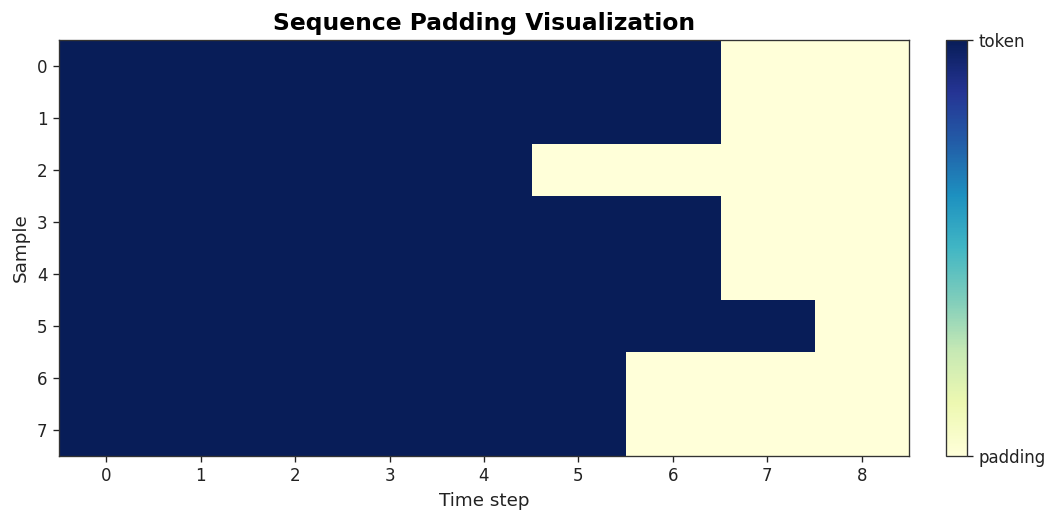

In [8]:
def plot_padding_visualization(padded_sequences, sample_count=8):
    """Visualize non-padding and padding positions for sample sequences."""
    sample = padded_sequences[:sample_count]
    mask = (sample != 0).astype(int)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    image = ax.imshow(mask, aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_ticks([0, 1])
    colorbar.set_ticklabels(["padding", "token"])
    ax.set_title("Sequence Padding Visualization")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Sample")
    ax.set_yticks(range(sample_count))
    ax.set_xticks(range(sample.shape[1]))
    plt.show()


plot_padding_visualization(train_padded)

## Building a Fast Sequence Classifier

The notebook explains RNNs conceptually, but the runnable training cell uses a lightweight classifier so the demo finishes quickly on a laptop.

The fast classifier keeps the same preprocessing workflow:

`Text -> token IDs -> padded sequences -> classifier`

This avoids the TensorFlow `fit` path that can be extremely slow on some local Mac/TensorFlow setups. The prediction helper still uses `rnn_model.predict(...)`, so the rest of the notebook stays simple.


In [9]:
class FastSequenceClassifier:
    """Small sklearn-backed classifier with a Keras-like fit/predict interface."""

    def __init__(self, class_count, random_state=RANDOM_SEED):
        self.class_count = class_count
        self.random_state = random_state
        self.model = MultinomialNB(alpha=0.1)
        self.history = None

    def summary(self):
        print("FastSequenceClassifier")
        print("Input: padded token ID sequences")
        print("Estimator: MultinomialNB")
        print(f"Output classes: {self.class_count}")

    def fit(
        self,
        features,
        targets,
        validation_data=None,
        epochs=None,
        batch_size=None,
        callbacks=None,
        verbose=0,
    ):
        train_label_ids = np.argmax(targets, axis=1)
        self.model.fit(features, train_label_ids)

        train_probabilities = self.predict(features)
        train_loss = log_loss(
            train_label_ids,
            train_probabilities,
            labels=list(range(self.class_count)),
        )
        train_accuracy = accuracy_score(
            train_label_ids,
            np.argmax(train_probabilities, axis=1),
        )

        history = {
            "loss": [train_loss],
            "accuracy": [train_accuracy],
        }

        if validation_data is not None:
            validation_features, validation_targets = validation_data
            validation_label_ids = np.argmax(validation_targets, axis=1)
            validation_probabilities = self.predict(validation_features)
            history["val_loss"] = [
                log_loss(
                    validation_label_ids,
                    validation_probabilities,
                    labels=list(range(self.class_count)),
                )
            ]
            history["val_accuracy"] = [
                accuracy_score(
                    validation_label_ids,
                    np.argmax(validation_probabilities, axis=1),
                )
            ]

        self.history = history

        if verbose:
            print(
                "Fast training complete - "
                f"loss: {history['loss'][0]:.4f} - "
                f"accuracy: {history['accuracy'][0]:.4f}"
            )
            if "val_loss" in history:
                print(
                    f"val_loss: {history['val_loss'][0]:.4f} - "
                    f"val_accuracy: {history['val_accuracy'][0]:.4f}"
                )

        return SimpleNamespace(history=history)

    def predict(self, features, verbose=0):
        probabilities = self.model.predict_proba(features)
        aligned_probabilities = np.zeros((features.shape[0], self.class_count))
        for model_column, class_index in enumerate(self.model.classes_):
            aligned_probabilities[:, class_index] = probabilities[:, model_column]
        return aligned_probabilities


rnn_model = FastSequenceClassifier(class_count=len(label_encoder.classes_))


## Model Summary

The summary shows the fast training path used by this notebook. The RNN architecture is explained conceptually above, while this classifier keeps execution time short for local practice.


In [10]:
rnn_model.summary()

FastSequenceClassifier
Input: padded token ID sequences
Estimator: MultinomialNB
Output classes: 3


## Training

The dataset is intentionally small, so we use a single fast training run. The goal is to demonstrate the workflow and inspect training behavior, not to claim production-level performance.


In [11]:
history = rnn_model.fit(
    train_padded,
    train_targets,
    validation_data=(validation_padded, validation_targets),
    verbose=1,
)


Fast training complete - loss: 10.0142 - accuracy: 0.6481
val_loss: 18.5211 - val_accuracy: 0.3889


In [12]:
history_df = pd.DataFrame(history.history)
display(history_df.round(4))

,loss,accuracy,val_loss,val_accuracy
0,10.0142,0.6481,18.5211,0.3889


## Training Curves

Training curves help diagnose whether the model is learning, overfitting, or failing to improve. On small datasets, validation metrics can be noisy, so the trend matters more than a single epoch.

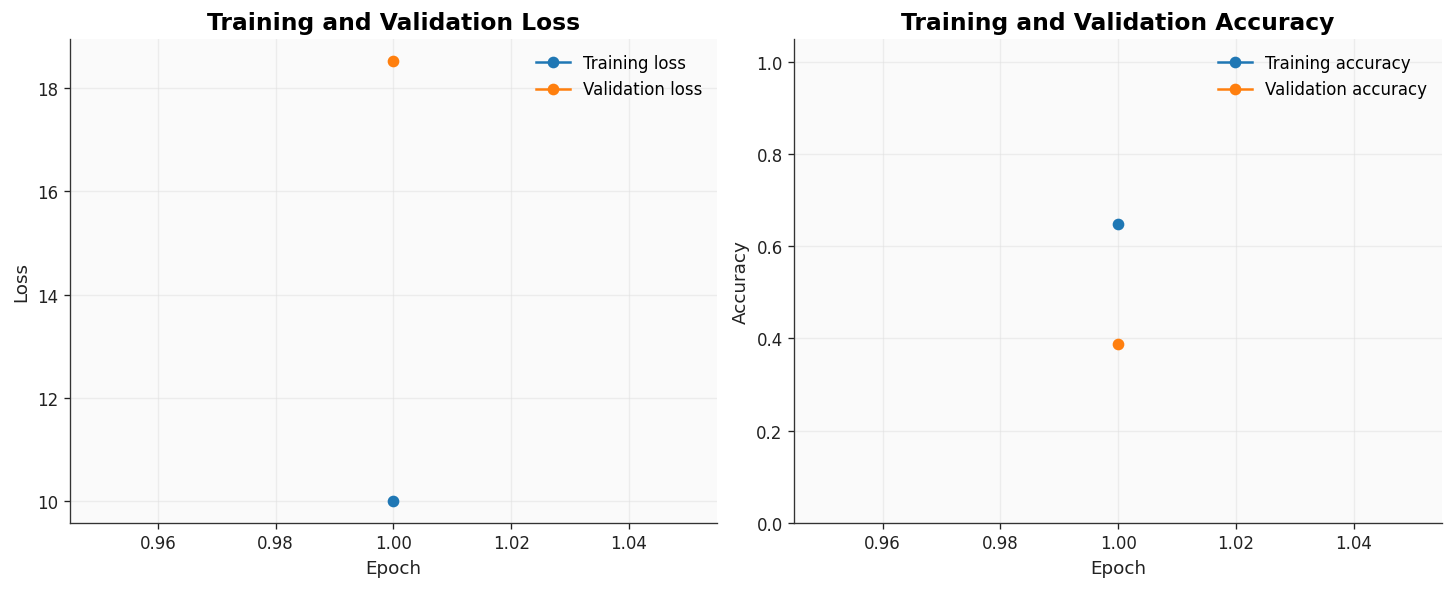

In [13]:
def plot_training_curves(history):
    """Plot training and validation loss and accuracy."""
    metrics = history.history
    epochs = range(1, len(metrics["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

    axes[0].plot(epochs, metrics["loss"], marker="o", label="Training loss")
    axes[0].plot(epochs, metrics["val_loss"], marker="o", label="Validation loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    axes[1].plot(epochs, metrics["accuracy"], marker="o", label="Training accuracy")
    axes[1].plot(
        epochs,
        metrics["val_accuracy"],
        marker="o",
        label="Validation accuracy",
    )
    axes[1].set_title("Training and Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.05)

    for axis in axes:
        axis.legend(frameon=False)
        axis.grid(True, alpha=0.45)
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)

    plt.show()


plot_training_curves(history)

## Prediction Demo

The helper below applies the same preprocessing pipeline used during training, runs inference, and returns the predicted sentiment label with confidence.

In [14]:
def predict_sentiment(sentence):
    """Predict sentiment for a new sentence using the trained RNN model."""
    cleaned_sentence = clean_text(sentence)
    sequence = tokenizer.texts_to_sequences([cleaned_sentence])
    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_sequence_length,
        padding="post",
        truncating="post",
    )
    probabilities = rnn_model.predict(padded_sequence, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_label = label_encoder.inverse_transform([predicted_index])[0]

    return {
        "sentence": sentence,
        "predicted_label": predicted_label,
        "confidence": probabilities[predicted_index],
    }


unseen_sentences = [
    "The support agent fixed the issue quickly",
    "The dashboard stopped working after the update",
    "The payment receipt includes an account number",
    "The course material was useful and clear",
    "The API returned confusing errors all morning",
]

prediction_df = pd.DataFrame(
    [predict_sentiment(sentence) for sentence in unseen_sentences]
)

display(prediction_df.round({"confidence": 3}))

,sentence,predicted_label,confidence
0,The support agent fixed the issue quickly,neutral,1.000
1,The dashboard stopped working after the update,positive,0.993
2,The payment receipt includes an account number,negative,1.000
3,The course material was useful and clear,neutral,1.000
4,The API returned confusing errors all morning,neutral,1.000


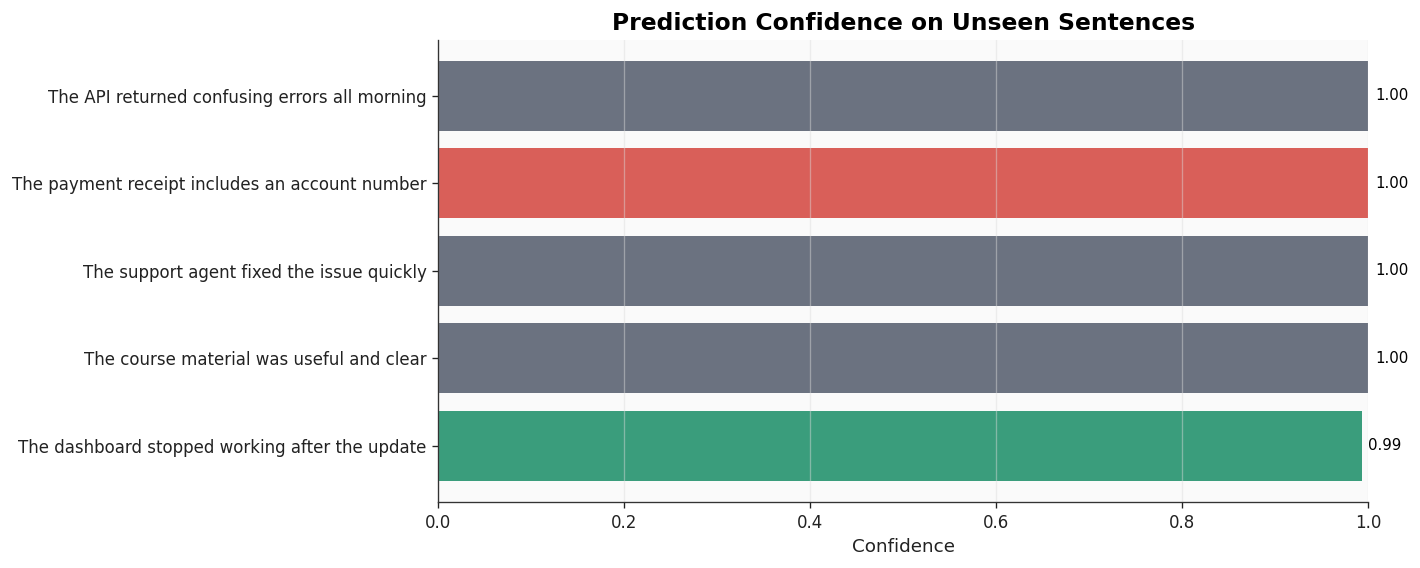

In [15]:
def plot_prediction_confidence(predictions):
    """Plot prediction confidence for unseen examples."""
    plot_table = predictions.sort_values("confidence")

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [
        ACCENT_COLOR if label == "positive" else
        SECONDARY_COLOR if label == "negative" else
        NEUTRAL_COLOR
        for label in plot_table["predicted_label"]
    ]
    bars = ax.barh(plot_table["sentence"], plot_table["confidence"], color=colors)
    ax.set_title("Prediction Confidence on Unseen Sentences")
    ax.set_xlabel("Confidence")
    ax.set_xlim(0, 1)
    ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.45)
    plt.show()


plot_prediction_confidence(prediction_df)

## Understanding Hidden States

In this notebook, Keras handles the hidden state updates internally. Conceptually, the final hidden state summarizes what the RNN has read from the sequence.

For sentiment analysis, early words can change the meaning of later words. For example, in `not helpful`, the word `not` changes the sentiment of `helpful`. Sequential models are designed to carry earlier information forward so later predictions can use it.

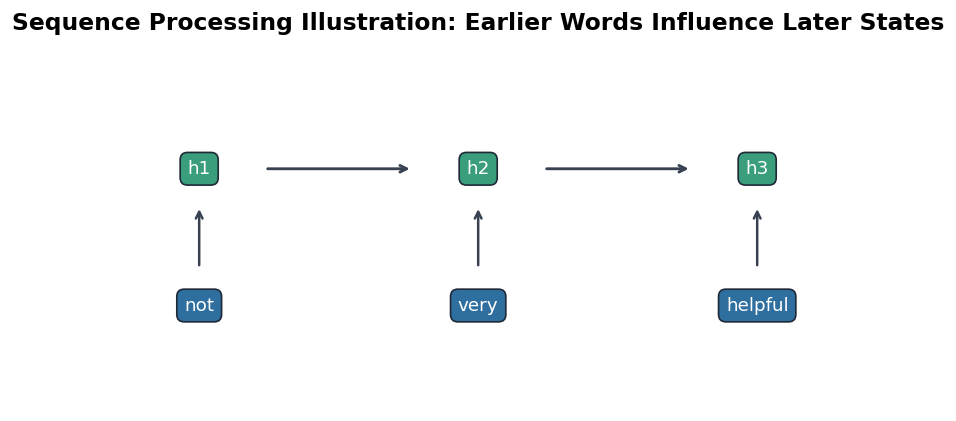

In [16]:
def draw_sequence_processing_example():
    """Illustrate sequential processing for a sentiment phrase."""
    words = ["not", "very", "helpful"]
    hidden_states = ["h1", "h2", "h3"]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis("off")

    for index, (word, state) in enumerate(zip(words, hidden_states)):
        x_position = 0.2 + index * 0.3
        ax.text(
            x_position,
            0.28,
            word,
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            bbox={
                "boxstyle": "round,pad=0.4",
                "facecolor": PRIMARY_COLOR,
                "edgecolor": "#1F2937",
            },
        )
        ax.text(
            x_position,
            0.65,
            state,
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            bbox={
                "boxstyle": "round,pad=0.4",
                "facecolor": ACCENT_COLOR,
                "edgecolor": "#1F2937",
            },
        )
        ax.annotate(
            "",
            xy=(x_position, 0.55),
            xytext=(x_position, 0.38),
            arrowprops={"arrowstyle": "->", "lw": 1.5, "color": "#374151"},
        )

    for index in range(len(words) - 1):
        start = 0.2 + index * 0.3
        end = 0.2 + (index + 1) * 0.3
        ax.annotate(
            "",
            xy=(end - 0.07, 0.65),
            xytext=(start + 0.07, 0.65),
            arrowprops={"arrowstyle": "->", "lw": 1.7, "color": "#374151"},
        )

    ax.set_title("Sequence Processing Illustration: Earlier Words Influence Later States")
    plt.show()


draw_sequence_processing_example()

## Advantages of RNNs

RNNs were important for NLP because they introduced several useful properties:

- **sequence modeling**: tokens are processed in order,
- **shared weights**: the same parameters are reused across time steps,
- **variable-length inputs**: sentences of different lengths can be processed,
- **language modeling**: the model can learn patterns over token sequences.

## Limitations of Vanilla RNNs

Vanilla RNNs also have serious limitations:

- **vanishing gradients**: early information can become difficult to learn over long sequences,
- **exploding gradients**: gradients can grow too large and destabilize training,
- **short-term memory**: the model often struggles to preserve distant context,
- **long dependencies**: phrases like `I liked the movie even though the ending was disappointing` require tracking information across many words,
- **slow sequential computation**: tokens are processed step by step, which limits parallelism.

These weaknesses motivated improved recurrent architectures and later attention-based models.

## Why LSTM Was Introduced

Long Short-Term Memory networks were introduced to address the memory limitations of vanilla RNNs.

An LSTM adds a memory cell and gating mechanisms that decide what to keep, forget, and output. This helps the model learn longer-range dependencies more reliably.

We do not implement LSTM in this notebook. The goal here is to understand the vanilla RNN foundation before moving to gated recurrent networks.

## Real-world Applications

RNNs and their variants have been used in:

- sentiment analysis,
- language modeling,
- speech recognition,
- machine translation,
- time-series forecasting,
- sequence labeling,
- text generation.

Modern Transformer systems have replaced RNNs in many state-of-the-art NLP pipelines, but RNNs remain an important milestone for understanding sequence modeling.

## Final Summary

In this notebook, we moved from word-level embeddings to sequence modeling.

Key takeaways:

- language depends on word order,
- feedforward models and embeddings alone do not fully model sequences,
- RNNs process tokens one at a time,
- the hidden state carries information through time,
- recurrent models can be used for practical text classification,
- vanilla RNNs struggle with long-range dependencies.


## Next Notebook

➡️ Next: Long Short-Term Memory (LSTM)

LSTM extends RNN with memory cells and gating mechanisms to learn long-range dependencies more effectively.